In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# ------------------------------------------------------------------
# 1. 환경 설정
# ------------------------------------------------------------------
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
BASE_PATH = r'D:\SSCode\DST\EDW'  # ★경로가 맞는지 꼭 확인하세요!

print("🔄 [통합 엔진] 데이터 로드 및 연산을 시작합니다... (약 10초 소요)")

# ------------------------------------------------------------------
# 2. 파일 읽기
# ------------------------------------------------------------------
orders = pd.read_csv(os.path.join(BASE_PATH, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_items_dataset.csv'))
customers = pd.read_csv(os.path.join(BASE_PATH, 'olist_customers_dataset.csv'))
sellers = pd.read_csv(os.path.join(BASE_PATH, 'olist_sellers_dataset.csv'))
reviews = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_reviews_dataset.csv'))
geo = pd.read_csv(os.path.join(BASE_PATH, 'olist_geolocation_dataset.csv'))
products = pd.read_csv(os.path.join(BASE_PATH, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(BASE_PATH, 'product_category_name_translation.csv'))

# ------------------------------------------------------------------
# 3. 데이터 병합 (Merge)
# ------------------------------------------------------------------
df = orders.merge(items, on='order_id')
df = df.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id')
df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id')
products = products.merge(trans, on='product_category_name', how='left')
df = df.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

# ------------------------------------------------------------------
# 4. 거리(Distance) 계산
# ------------------------------------------------------------------
geo_avg = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
df = df.merge(geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'})
df = df.merge(geo_avg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'})

R = 6371
phi1, phi2 = np.radians(df['c_lat']), np.radians(df['s_lat'])
dphi = np.radians(df['s_lat'] - df['c_lat'])
dlambda = np.radians(df['s_lng'] - df['c_lng'])
a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
df['distance_km'] = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

print("✅ 데이터 로드 및 거리 계산 완료!")

# ------------------------------------------------------------------
# 5. [데이터 가공] 카테고리별 집계 및 분리
# ------------------------------------------------------------------

# (1) 카테고리별 집계
bubble_data = df.groupby('product_category_name_english').agg({
    'order_id': 'count',       # 원 크기 (판매량)
    'review_score': 'mean',    # Y축 (평점)
    'distance_km': 'mean'      # X축 (거리)
}).reset_index()
bubble_data.columns = ['Category', 'Volume', 'Score', 'Distance']

# (2) 기준점 (평균)
avg_dist = bubble_data['Distance'].mean()

# (3) 데이터 쪼개기

# [Hero 데이터]: 평균보다 멀고(>avg), 판매량 50개 이상
hero_data = bubble_data[
    (bubble_data['Distance'] > avg_dist) & 
    (bubble_data['Volume'] >= 50)
].copy()

# [Cash Cow 데이터]: 평균보다 가깝고(<=avg), 판매량 100개 이상
cow_data = bubble_data[
    (bubble_data['Distance'] <= avg_dist) & 
    (bubble_data['Volume'] >= 100)
].copy()

print(f"\n✅ 최종 데이터 분리 완료!")
print(f" - 🔵 Hero 데이터(장거리): {len(hero_data)}개 준비됨")
print(f" - 🟢 Cash Cow 데이터(단거리): {len(cow_data)}개 준비됨")
print("👉 이제 Cell 2, Cell 3를 실행하시면 그래프가 나옵니다.")

🔄 [통합 엔진] 데이터 로드 및 연산을 시작합니다... (약 10초 소요)
✅ 데이터 로드 및 거리 계산 완료!

✅ 최종 데이터 분리 완료!
 - 🔵 Hero 데이터(장거리): 26개 준비됨
 - 🟢 Cash Cow 데이터(단거리): 29개 준비됨
👉 이제 Cell 2, Cell 3를 실행하시면 그래프가 나옵니다.


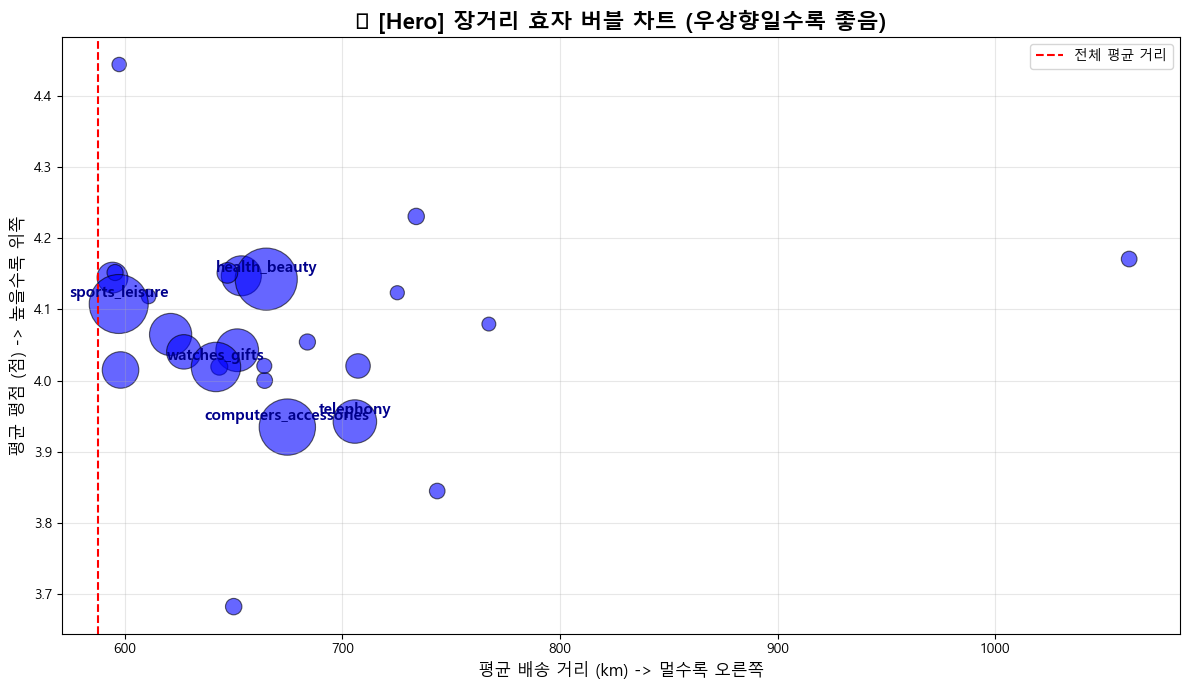

In [3]:
# === Hero (장거리) 버블 차트 ===
plt.figure(figsize=(12, 7))

# 1. 버블 차트 그리기 (파란색)
sns.scatterplot(data=hero_data, x='Distance', y='Score', 
                size='Volume', sizes=(100, 2000), 
                color='blue', alpha=0.6, edgecolor='k', legend=False)

# 2. 이름표 달기 (TOP 5만)
top_hero = hero_data.sort_values('Volume', ascending=False).head(5)
for i in range(len(top_hero)):
    row = top_hero.iloc[i]
    plt.text(row['Distance'], row['Score']+0.01, row['Category'], 
             color='darkblue', fontweight='bold', fontsize=11, ha='center')

# 3. 꾸미기
plt.title('🚀 [Hero] 장거리 효자 버블 차트 (우상향일수록 좋음)', fontsize=16, fontweight='bold')
plt.xlabel('평균 배송 거리 (km) -> 멀수록 오른쪽', fontsize=12)
plt.ylabel('평균 평점 (점) -> 높을수록 위쪽', fontsize=12)
plt.grid(True, alpha=0.3)

# 기준선 (평균 거리보다 무조건 멉니다)
plt.axvline(x=avg_dist, color='red', linestyle='--', label='전체 평균 거리')
plt.legend()

plt.tight_layout()
plt.show()

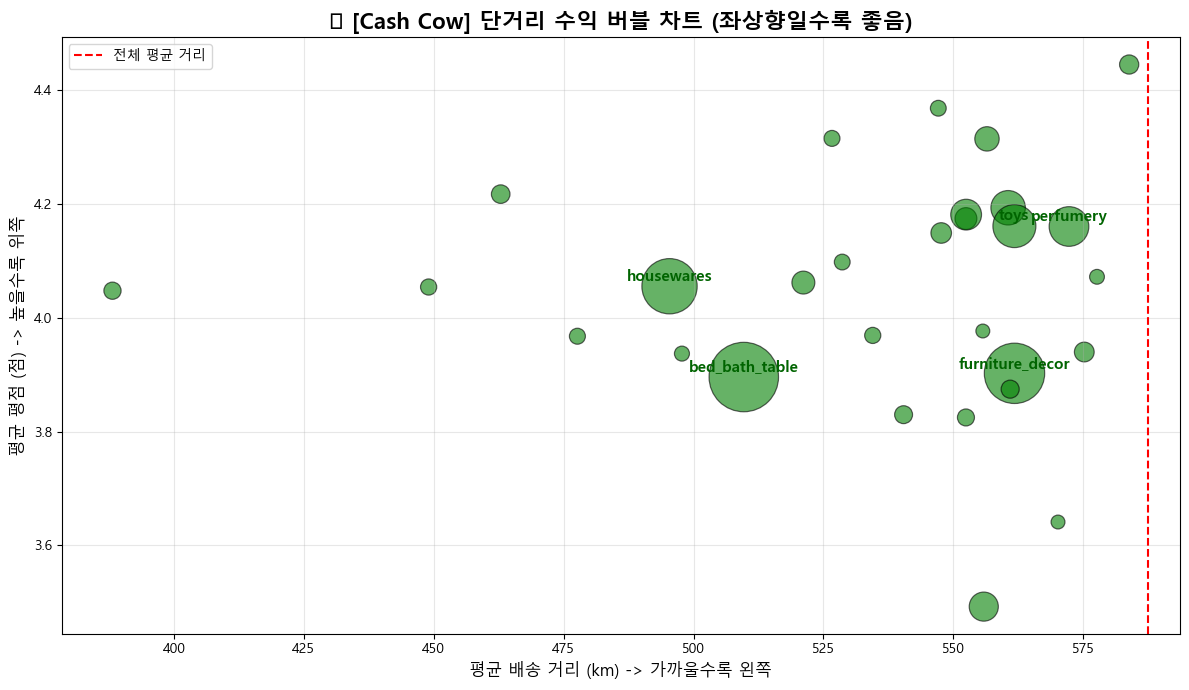

In [4]:
# === Cash Cow (단거리) 버블 차트 ===
plt.figure(figsize=(12, 7))

# 1. 버블 차트 그리기 (초록색)
sns.scatterplot(data=cow_data, x='Distance', y='Score', 
                size='Volume', sizes=(100, 2500), 
                color='green', alpha=0.6, edgecolor='k', legend=False)

# 2. 이름표 달기 (TOP 5만)
top_cow = cow_data.sort_values('Volume', ascending=False).head(5)
for i in range(len(top_cow)):
    row = top_cow.iloc[i]
    plt.text(row['Distance'], row['Score']+0.01, row['Category'], 
             color='darkgreen', fontweight='bold', fontsize=11, ha='center')

# 3. 꾸미기
plt.title('💰 [Cash Cow] 단거리 수익 버블 차트 (좌상향일수록 좋음)', fontsize=16, fontweight='bold')
plt.xlabel('평균 배송 거리 (km) -> 가까울수록 왼쪽', fontsize=12)
plt.ylabel('평균 평점 (점) -> 높을수록 위쪽', fontsize=12)
plt.grid(True, alpha=0.3)

# 기준선 (평균 거리보다 무조건 가깝습니다)
plt.axvline(x=avg_dist, color='red', linestyle='--', label='전체 평균 거리')
plt.legend()

plt.tight_layout()
plt.show()

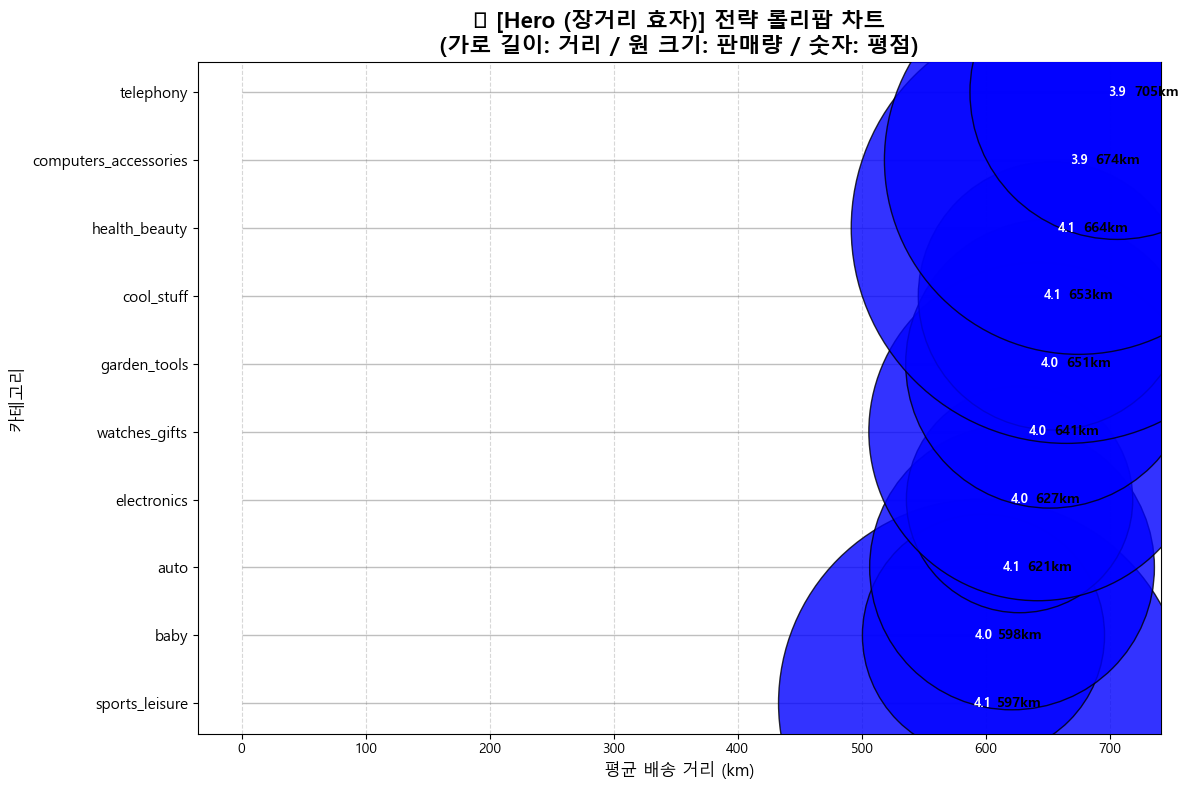

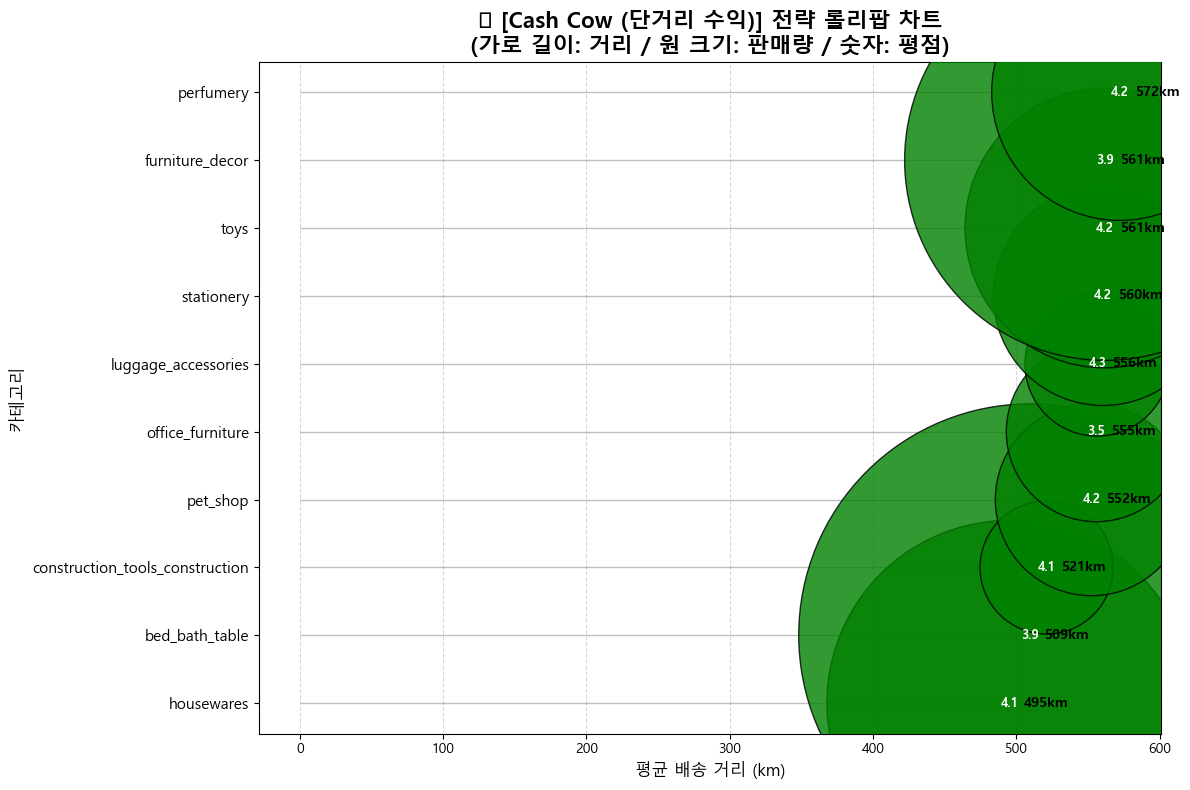

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# 함수 정의: 롤리팝 차트 그리기 (코드 중복 방지)
# ------------------------------------------------------------------
def draw_lollipop(data, strategy_name, color_theme):
    # 데이터 정렬 (거리가 먼 순서대로, 혹은 판매량 순서대로)
    # 여기서는 '거리(Distance)' 기준으로 정렬해서 시각화합니다.
    df_sorted = data.sort_values(by='Distance', ascending=True)
    
    # 캔버스 설정
    plt.figure(figsize=(12, 8))
    
    # 1. 롤리팝의 '막대(Stem)' 그리기
    plt.hlines(y=df_sorted['Category'], xmin=0, xmax=df_sorted['Distance'], 
               color='gray', alpha=0.5, linewidth=1)
    
    # 2. 롤리팝의 '사탕(Head)' 그리기 (버블 차트처럼 크기로 판매량 표현)
    # s 파라미터로 원의 크기 조절 (기본값보다 조금 키움)
    plt.scatter(df_sorted['Distance'], df_sorted['Category'], 
                s=df_sorted['Volume']*10,  # 판매량에 비례해 크기 키움 (조절 가능)
                color=color_theme, alpha=0.8, edgecolors='black', zorder=3)
    
    # 3. 정보 텍스트 추가 (겹침 없이 깔끔하게)
    for i in range(len(df_sorted)):
        row = df_sorted.iloc[i]
        
        # (1) 평점 정보 (원 안에 혹은 옆에 표시)
        plt.text(row['Distance'], i, f"{row['Score']:.1f}", 
                 color='white', fontweight='bold', ha='center', va='center', fontsize=9)
        
        # (2) 거리 정보 (막대 끝에 표시)
        plt.text(row['Distance'] + (row['Distance']*0.02), i, f"{int(row['Distance'])}km", 
                 color='black', va='center', fontsize=10, fontweight='bold')

    # 4. 꾸미기
    plt.title(f'🍭 [{strategy_name}] 전략 롤리팝 차트\n(가로 길이: 거리 / 원 크기: 판매량 / 숫자: 평점)', 
              fontsize=16, fontweight='bold')
    plt.xlabel('평균 배송 거리 (km)', fontsize=12)
    plt.ylabel('카테고리', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Y축 카테고리 글씨 잘 보이게
    plt.yticks(fontsize=11)
    
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 실행: Hero & Cash Cow 각각 그리기
# ------------------------------------------------------------------

# 1. Hero (장거리) - 파란색 테마
# (상위 10개만 추출해서 그려야 제일 예쁩니다)
hero_top10 = hero_data.sort_values('Volume', ascending=False).head(10)
draw_lollipop(hero_top10, "Hero (장거리 효자)", "blue")

# 2. Cash Cow (단거리) - 초록색 테마
cow_top10 = cow_data.sort_values('Volume', ascending=False).head(10)
draw_lollipop(cow_top10, "Cash Cow (단거리 수익)", "green")

🔹 [1] Hero 전략: 멀리 가도 잘 팔리는 TOP 5


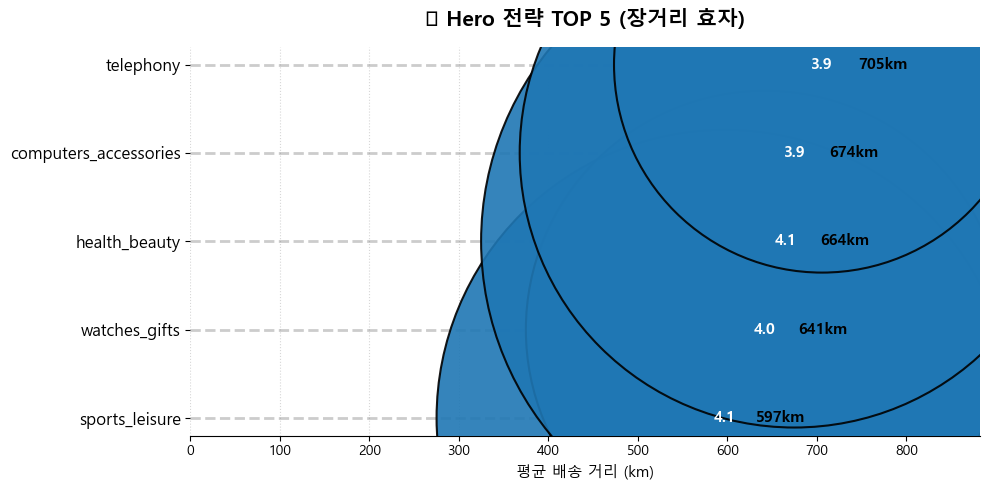


🔸 [2] Cash Cow 전략: 가까워서 알짜인 TOP 5


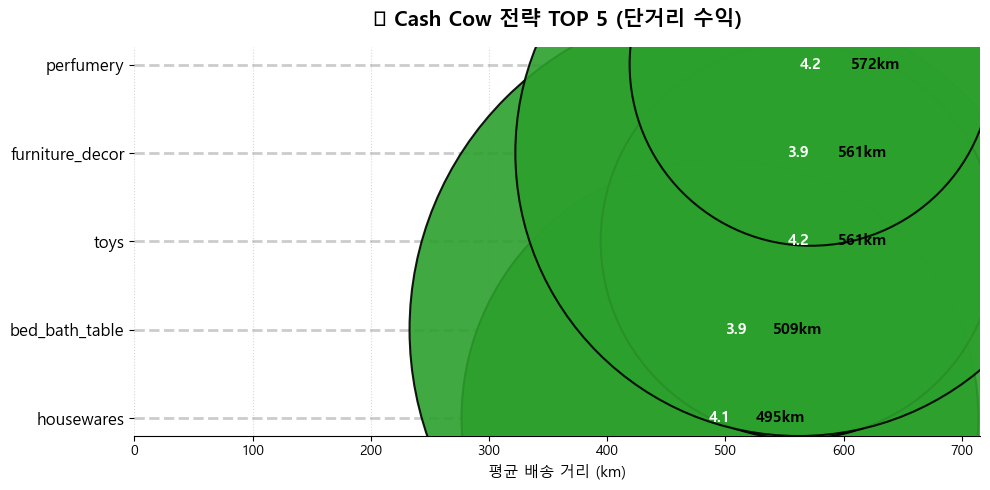

In [8]:
# ------------------------------------------------------------------
# 실행: Hero & Cash Cow 각각 그리기
# ------------------------------------------------------------------

# 1. Hero (장거리) - 파란색
print("🔹 [1] Hero 전략: 멀리 가도 잘 팔리는 TOP 5")
draw_premium_lollipop(hero_data, "🚀 Hero 전략 TOP 5 (장거리 효자)", "#1f77b4", "Hero")

# 2. Cash Cow (단거리) - 초록색
print("\n🔸 [2] Cash Cow 전략: 가까워서 알짜인 TOP 5")
draw_premium_lollipop(cow_data, "💰 Cash Cow 전략 TOP 5 (단거리 수익)", "#2ca02c", "CashCow")

🔹 [1] Hero 전략: 깔끔해진 롤리팝


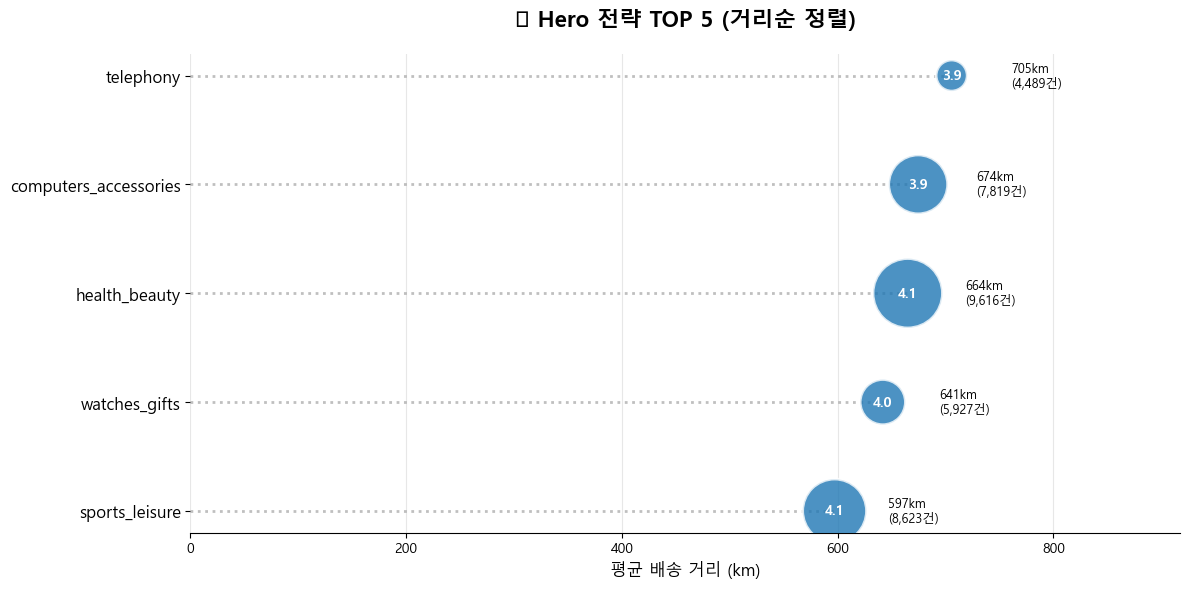


🔸 [2] Cash Cow 전략: 깔끔해진 롤리팝


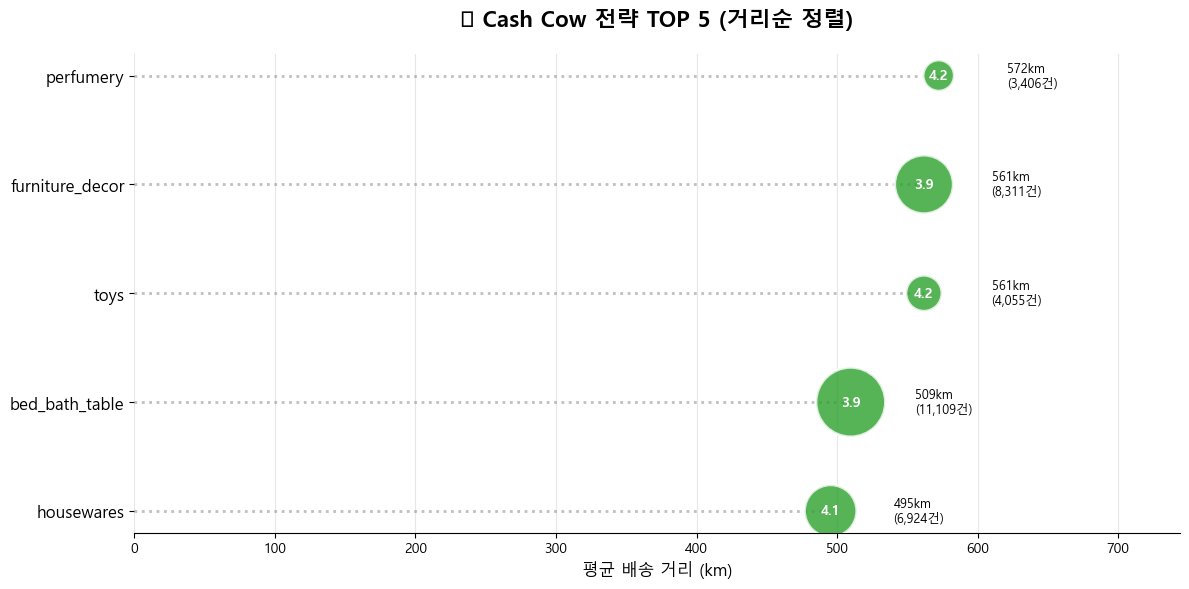

In [9]:
# ------------------------------------------------------------------
# 실행
# ------------------------------------------------------------------

print("🔹 [1] Hero 전략: 깔끔해진 롤리팝")
draw_smart_lollipop(hero_data, "🚀 Hero 전략 TOP 5 (거리순 정렬)", "#1f77b4")

print("\n🔸 [2] Cash Cow 전략: 깔끔해진 롤리팝")
draw_smart_lollipop(cow_data, "💰 Cash Cow 전략 TOP 5 (거리순 정렬)", "#2ca02c")